In [1]:
import pandas as pd
from pathlib import Path

In [2]:
df_2021 = pd.read_csv(Path("../data/processed/data_air_quality_2021.csv"), sep=";")
df_2022 = pd.read_csv(Path("../data/processed/data_air_quality_2022.csv"), sep=";")
df_2023 = pd.read_csv(Path("../data/processed/data_air_quality_2023.csv"), sep=";")

In [3]:
print(df_2021.shape, df_2022.shape, df_2023.shape)

(1305096, 23) (1305456, 23) (1320912, 23)


In [4]:
df_2021['Date'] = pd.to_datetime(df_2021['Date de début'])
df_2022['Date'] = pd.to_datetime(df_2022['Date de début'])
df_2023['Date'] = pd.to_datetime(df_2023['Date de début'])

In [5]:
df_2021['Date'] = df_2021['Date'].dt.date
df_2022['Date'] = df_2022['Date'].dt.date
df_2023['Date'] = df_2023['Date'].dt.date

In [6]:
df_2021.head()

,Date de début,Date de fin,Organisme,code zas,Zas,code site,nom site,type d'implantation,Polluant,type d'influence,...,type de valeur,valeur,valeur brute,unité de mesure,taux de saisie,couverture temporelle,couverture de données,code qualité,validité,Date
0,2021/01/01 00:00:00,2021/01/01 01:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,moyenne horaire validée,25.0,25.025,µg-m3,NaN,NaN,NaN,A,1,2021-01-01
1,2021/01/01 01:00:00,2021/01/01 02:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,moyenne horaire validée,26.4,26.375,µg-m3,NaN,NaN,NaN,A,1,2021-01-01
2,2021/01/01 02:00:00,2021/01/01 03:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,moyenne horaire validée,21.8,21.825,µg-m3,NaN,NaN,NaN,A,1,2021-01-01
3,2021/01/01 03:00:00,2021/01/01 04:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,moyenne horaire validée,20.1,20.050,µg-m3,NaN,NaN,NaN,A,1,2021-01-01
4,2021/01/01 04:00:00,2021/01/01 05:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,moyenne horaire validée,23.3,23.300,µg-m3,NaN,NaN,NaN,A,1,2021-01-01


In [7]:
# For PM10 and NO2, we calculate daily average, for O3 we calculate daily maximum

def agg_pollutant(group):
    polluant = group.name[1]
    if polluant == "O3":
        return group["valeur"].max()
    else:
        return group["valeur"].mean()

df_2021_daily = (
    df_2021
    .groupby(["Date", "Polluant"])
    .apply(agg_pollutant)
    .reset_index(name="valeur")
)

df_2022_daily = (
    df_2022
    .groupby(["Date", "Polluant"])
    .apply(agg_pollutant)
    .reset_index(name="valeur")
)

df_2023_daily = (
    df_2023
    .groupby(["Date", "Polluant"])
    .apply(agg_pollutant)
    .reset_index(name="valeur")
)

In [8]:
# For each polluant, we calculate the average value for each day
'''
df_2021_daily = df_2021.groupby(['Date', 'Polluant'])['valeur'].mean().reset_index()
df_2022_daily = df_2022.groupby(['Date', 'Polluant'])['valeur'].mean().reset_index()
df_2023_daily = df_2023.groupby(['Date', 'Polluant'])['valeur'].mean().reset_index()
df_2021_daily.head(10)
'''

"\ndf_2021_daily = df_2021.groupby(['Date', 'Polluant'])['valeur'].mean().reset_index()\ndf_2022_daily = df_2022.groupby(['Date', 'Polluant'])['valeur'].mean().reset_index()\ndf_2023_daily = df_2023.groupby(['Date', 'Polluant'])['valeur'].mean().reset_index()\ndf_2021_daily.head(10)\n"

In [9]:
# For each year, we pivot the data to have one column per pollutant and one row per day
df_2021_daily = df_2021_daily.pivot(index='Date', columns='Polluant', values='valeur')
df_2021_daily.columns.name = None
df_2021_daily.index.name = None
df_2021_daily = df_2021_daily.reset_index().rename(columns={'index': 'Date'})
# 2022
df_2022_daily = df_2022_daily.pivot(index='Date', columns='Polluant', values='valeur')
df_2022_daily.columns.name = None
df_2022_daily.index.name = None
df_2022_daily = df_2022_daily.reset_index().rename(columns={'index': 'Date'})
# 2023
df_2023_daily = df_2023_daily.pivot(index='Date', columns='Polluant', values='valeur')
df_2023_daily.columns.name = None
df_2023_daily.index.name = None
df_2023_daily = df_2023_daily.reset_index().rename(columns={'index': 'Date'})

In [10]:
df_2021_daily.head()

,Date,CO,NO,NO2,NOX as NO2,O3,PM10,PM2.5,SO2
0,2021-01-01,0.397792,24.654300,38.308231,76.220025,50.8,29.581281,27.511230,1.247222
1,2021-01-02,0.645406,55.401595,46.308466,131.365644,36.0,48.457178,42.540244,2.413889
2,2021-01-03,0.372447,20.386887,29.734069,61.106495,31.2,34.981863,31.270968,1.419444
3,2021-01-04,0.344740,21.865789,24.945489,58.575940,25.1,22.128986,18.713021,0.968056
4,2021-01-05,0.435681,28.221429,29.559900,72.934837,20.9,28.073529,24.542328,1.686667


In [11]:
df_2021_daily['Date'] = pd.to_datetime(df_2021_daily['Date'])
df_2022_daily['Date'] = pd.to_datetime(df_2022_daily['Date'])
df_2023_daily['Date'] = pd.to_datetime(df_2023_daily['Date'])
df_2021_daily['Date'].dtype

dtype('<M8[s]')

In [12]:
# Concatenating the three years into a single dataframe
df = pd.concat([df_2021_daily, df_2022_daily, df_2023_daily], ignore_index=True)
df.shape

(1095, 9)

In [13]:
df_weather = pd.read_csv(Path("../data/processed/data_weather.csv"), sep=";")
df_weather_ap = pd.read_csv(Path("../data/processed/data_weather_ap.csv"), sep=";")

In [14]:
df_weather["AAAAMMJJ"] = pd.to_datetime(df_weather["AAAAMMJJ"].astype(str), format="%Y%m%d")
df_weather.rename(columns={"AAAAMMJJ":"Date"}, inplace=True)

df_weather_ap["AAAAMMJJ"] = pd.to_datetime(df_weather_ap["AAAAMMJJ"].astype(str), format="%Y%m%d")
df_weather_ap.rename(columns={"AAAAMMJJ":"Date"}, inplace=True)

df_weather.head()

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,Date,RR,QRR,TN,QTN,...,HXI2,QHXI2,FXI3S,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR
0,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-01,0.0,1.0,0.1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-02,0.2,1.0,-1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-03,0.0,1.0,2.8,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-04,0.0,1.0,2.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-05,0.2,1.0,2.6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
weather_vars = ['RR', 'TNTXM', 'FFM']
weather_ap_vars = ['PMERM', 'GLOT']

df_weather_daily = df_weather.groupby("Date")[weather_vars].mean().reset_index()
df_weather_ap_daily = df_weather_ap.groupby("Date")[weather_ap_vars].mean().reset_index()

df_weather_daily.head()

,Date,RR,TNTXM,FFM
0,2021-01-01,0.055556,1.833333,2.033333
1,2021-01-02,0.088889,1.566667,1.600000
2,2021-01-03,0.088889,3.083333,3.000000
3,2021-01-04,0.100000,2.816667,4.533333
4,2021-01-05,0.144444,2.566667,4.266667


In [26]:
df_weather_daily.shape

(1095, 4)

In [27]:
df_weather_full = pd.merge(df_weather_daily, df_weather_ap_daily, on=["Date"], how="outer")
df_weather_full.head()

,Date,RR,TNTXM,FFM,PMERM,GLOT
0,2021-01-01,0.055556,1.833333,2.033333,1011.3,386.0
1,2021-01-02,0.088889,1.566667,1.600000,1014.8,465.0
2,2021-01-03,0.088889,3.083333,3.000000,1014.2,194.5
3,2021-01-04,0.100000,2.816667,4.533333,1013.6,64.0
4,2021-01-05,0.144444,2.566667,4.266667,1014.9,48.5


In [28]:
# Merging air quality and weather data on date
df_merged = df_weather_full.merge(df, on="Date")
df_merged.head()

,Date,RR,TNTXM,FFM,PMERM,GLOT,CO,NO,NO2,NOX as NO2,O3,PM10,PM2.5,SO2
0,2021-01-01,0.055556,1.833333,2.033333,1011.3,386.0,0.397792,24.654300,38.308231,76.220025,50.8,29.581281,27.511230,1.247222
1,2021-01-02,0.088889,1.566667,1.600000,1014.8,465.0,0.645406,55.401595,46.308466,131.365644,36.0,48.457178,42.540244,2.413889
2,2021-01-03,0.088889,3.083333,3.000000,1014.2,194.5,0.372447,20.386887,29.734069,61.106495,31.2,34.981863,31.270968,1.419444
3,2021-01-04,0.100000,2.816667,4.533333,1013.6,64.0,0.344740,21.865789,24.945489,58.575940,25.1,22.128986,18.713021,0.968056
4,2021-01-05,0.144444,2.566667,4.266667,1014.9,48.5,0.435681,28.221429,29.559900,72.934837,20.9,28.073529,24.542328,1.686667


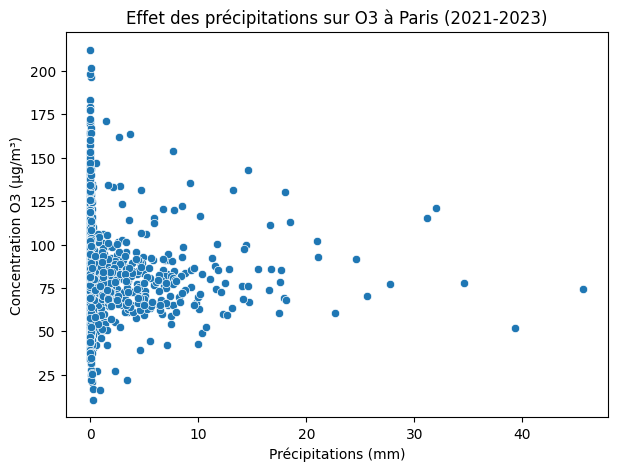

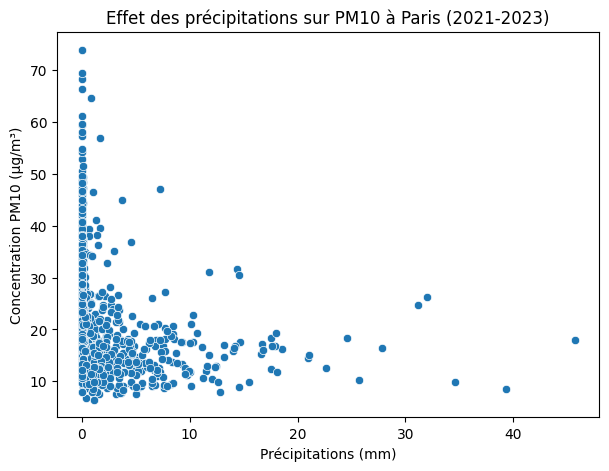

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

pollutants = ["O3", "PM10"]

for p in pollutants:
    plt.figure(figsize=(7,5))
    sns.scatterplot(x="RR", y=p, data=df_merged)
    # sns.regplot(x="RR", y=p, data=df_merged, scatter=False, color="red", ci=None)
    plt.xlabel("Précipitations (mm)")
    plt.ylabel(f"Concentration {p} (µg/m³)")
    plt.title(f"Effet des précipitations sur {p} à Paris (2021-2023)")
    plt.show()

In [34]:
# Writing the merged dataframe to a csv file
# df_merged.to_csv(Path("../data/processed/dataviz.csv"), index=False, sep=";")

In [35]:
correlations = {}

for var in weather_vars + weather_ap_vars:
    correlations[var] = {}
    for p in pollutants:
        corr = df_merged[var].corr(df_merged[p])  # pandas ignore automatiquement les NaN
        correlations[var][p] = corr

# Affichage clair
for var, poll_corrs in correlations.items():
    print(f"\nCorrelations for {var}:")
    for p, corr in poll_corrs.items():
        print(f"  {p}: {corr:.2f}")


Correlations for RR:
  O3: -0.07
  PM10: -0.23

Correlations for TNTXM:
  O3: 0.70
  PM10: -0.13

Correlations for FFM:
  O3: -0.15
  PM10: -0.43

Correlations for PMERM:
  O3: -0.02
  PM10: 0.39

Correlations for GLOT:
  O3: 0.75
  PM10: 0.08


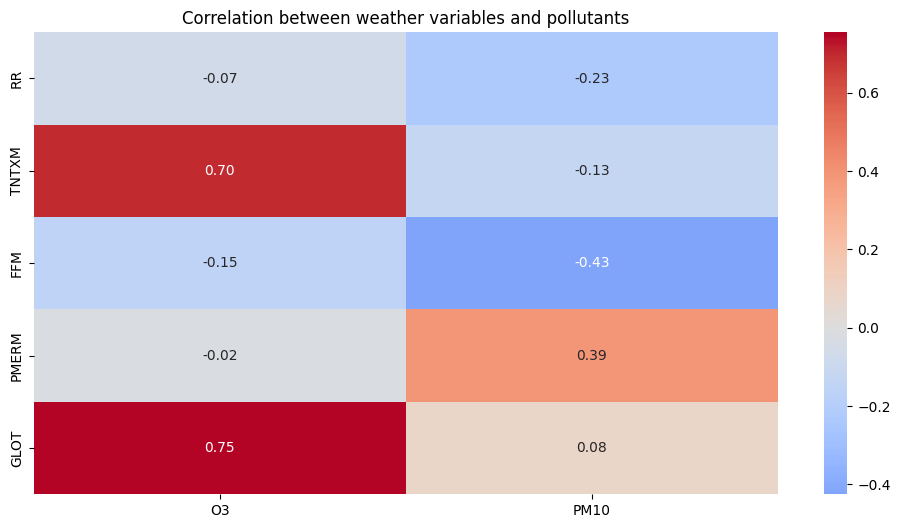

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

corr_df = pd.DataFrame(correlations).T

plt.figure(figsize=(12,6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between weather variables and pollutants")
plt.show()